# **Electrical Vehicle Purchase Prediction**

**Author:** Ambrose Chan Pak Yeung  
**Dataset:** Kaggle *Predicting Electric Vehicle Purchases*

# **1. Import libraries and load data**

In [1]:
# Import libraries
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from category_encoders import MEstimateEncoder

RANDOM_STATE = 42

In [2]:
# Load dataset
train = pd.read_csv("train.csv")
print(train.shape)
display(train.head())

(668665, 15)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [3]:
# Load test dataset
test = pd.read_csv("test.csv")
print(test.shape)
display(test.head())

(286571, 14)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low


# **2. Data Understanding**

In [4]:
target = "Will_Buy_EV"
numeric_cols = [c for c in train.select_dtypes(include=np.number).columns if c != "id"]
categorical_cols = [c for c in train.select_dtypes(include=["object", "string", "category"]).columns if c != target]

train.info()
print ()

print("Numerical features:", numeric_cols)
print("Categorical features:", categorical_cols)

print ()
print("Missing values:")
display(train.isna().sum().sort_values(ascending=False))
print("Duplicate rows:", train.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

Duplicate rows: 0


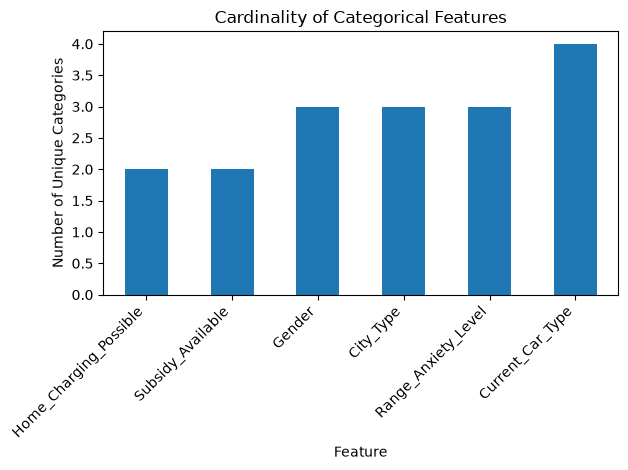

In [5]:
# Cardinality of categorical features
cardinality = train[categorical_cols].nunique(dropna=False).sort_values()
cardinality.plot(kind="bar")
plt.title("Cardinality of Categorical Features")
plt.ylabel("Number of Unique Categories")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# **3. Exploratory Data Analysis**

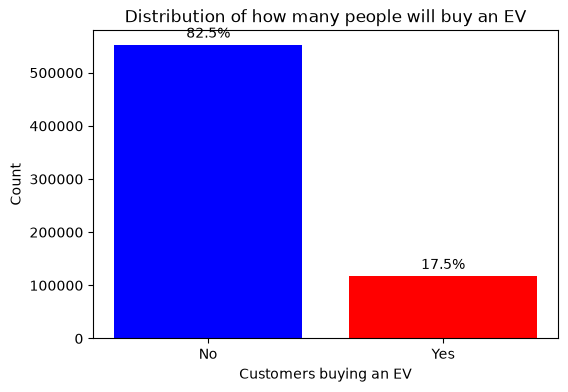

In [6]:
# Plotting the distribution of the target variable
counts = train['Will_Buy_EV'].value_counts()
pcts = train['Will_Buy_EV'].value_counts(normalize=True) * 100
pct_labels = [f'{p:.1f}%' for p in pcts]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=['blue', 'red'])
ax.bar_label(bars, labels=pct_labels, padding=3)

plt.title('Distribution of how many people will buy an EV')
plt.xlabel('Customers buying an EV')
plt.ylabel('Count')
plt.show()

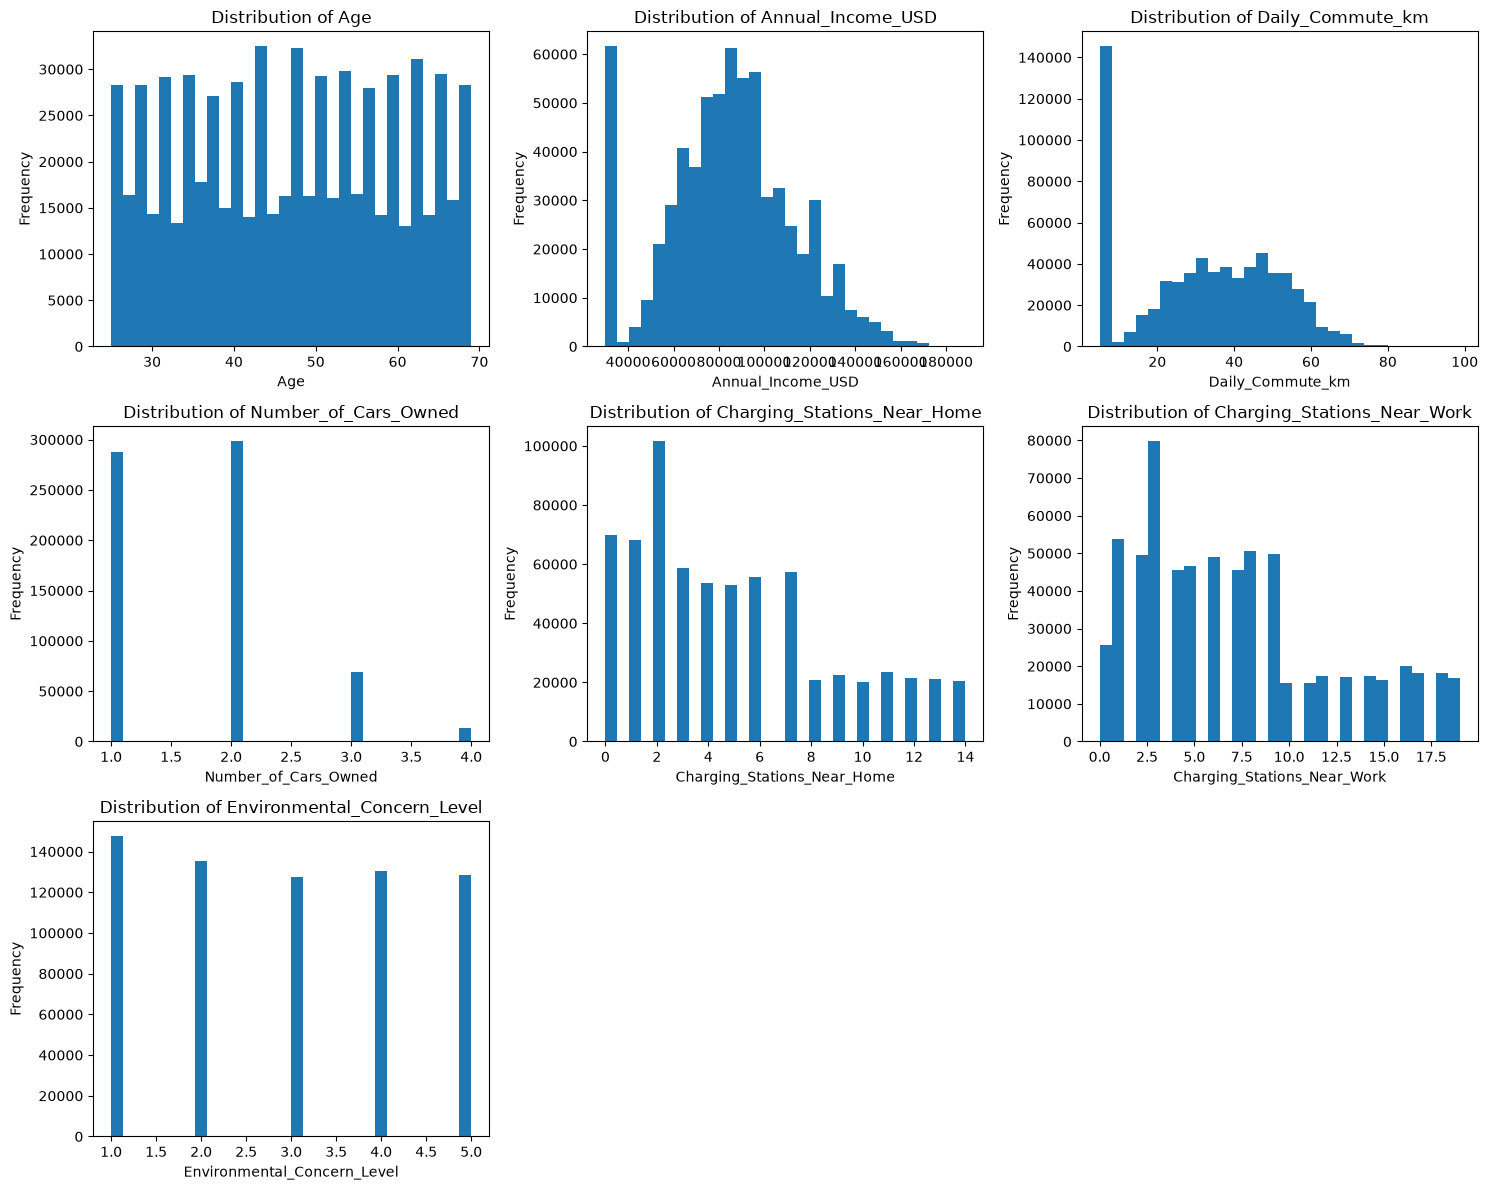

In [7]:
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(15, 4 * n_rows)
)

axes = np.asarray(axes).ravel()

for ax, col in zip(axes, numeric_cols):
    ax.hist(train[col].dropna(), bins=30)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
# Calculate skewness for numeric features
skewness=train[numeric_cols].skew().sort_values(ascending=False)
print (skewness)

Number_of_Cars_Owned           0.814497
Charging_Stations_Near_Work    0.700188
Charging_Stations_Near_Home    0.698730
Environmental_Concern_Level    0.054283
Age                           -0.003786
Annual_Income_USD             -0.013086
Daily_Commute_km              -0.084589
dtype: float64


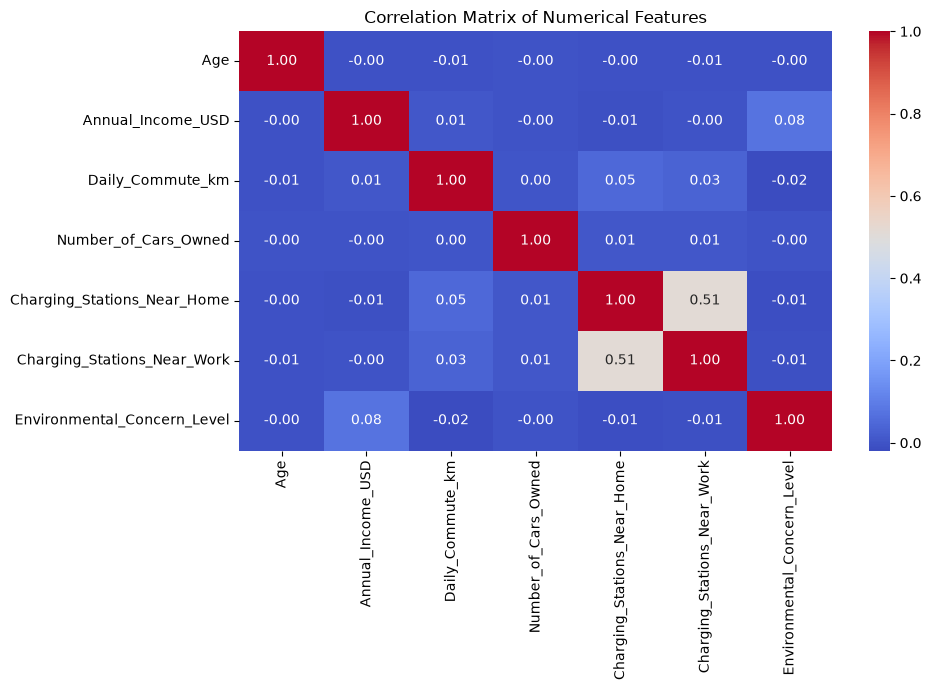

In [9]:
# Calculate correlation matrix for numeric features and plot heatmap
corr=train[numeric_cols].corr()
plt.figure(figsize=(10,7)); sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

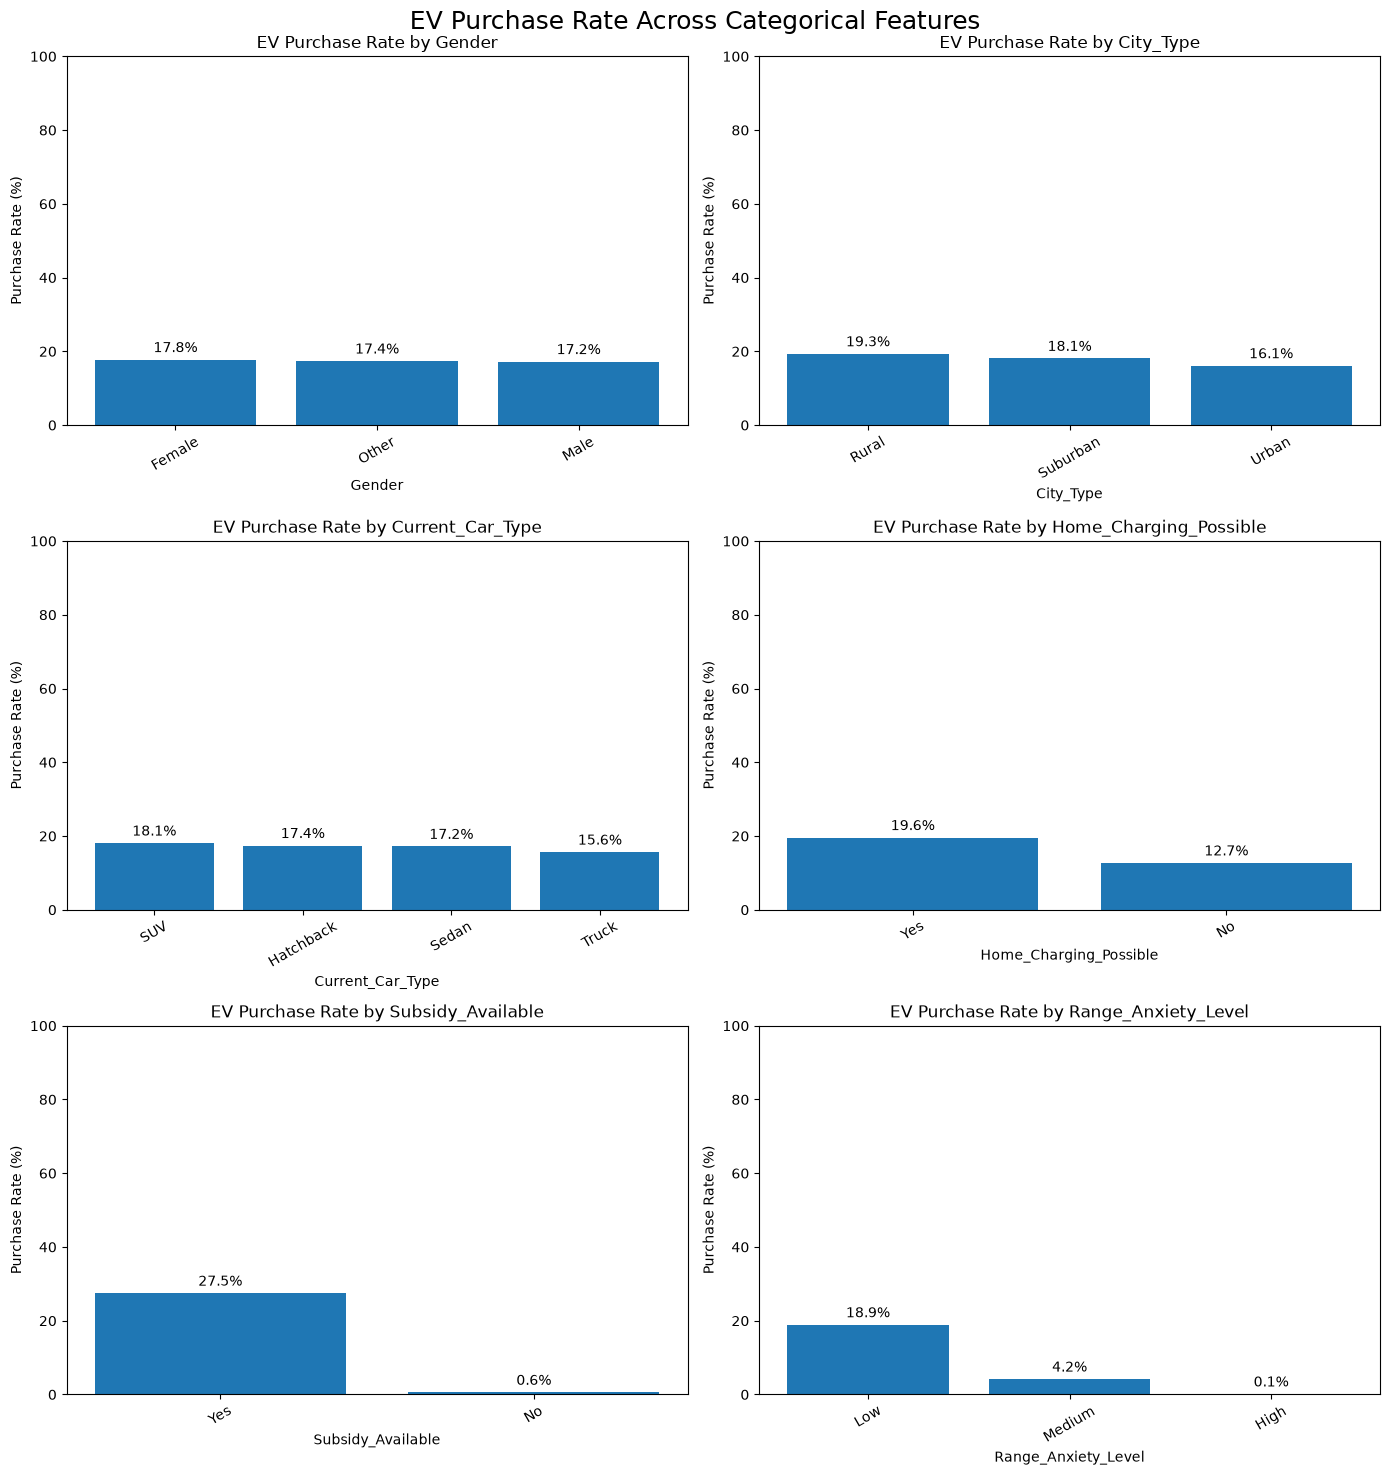

In [10]:
# Purchase rate for categorical features 
n_cols = 2
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows,ncols=n_cols,figsize=(14, 5 * n_rows))
axes = np.asarray(axes).ravel()

for ax, col in zip(axes, categorical_cols):

    # Calculate EV purchase rate for each category
    rate = (
        train.groupby(col, dropna=False)[target]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )

    # Replace missing-value label for display
    labels = rate.index.astype(str)
    labels = ["Missing" if label == "nan" else label for label in labels]

    # Bar chart
    bars = ax.bar(labels, rate.values)

    # Titles and labels
    ax.set_title(f"EV Purchase Rate by {col}", fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel("Purchase Rate (%)")
    ax.tick_params(axis="x", rotation=30)
    ax.bar_label(bars, fmt="%.1f%%", padding=3)

    # Make y-axis consistent
    ax.set_ylim(0, 100)


# Hide unused subplot(s)
for ax in axes[len(categorical_cols):]:
    ax.set_visible(False)


fig.suptitle("EV Purchase Rate Across Categorical Features", fontsize=18)

plt.tight_layout()
plt.show()

# **4. Mutual Information**

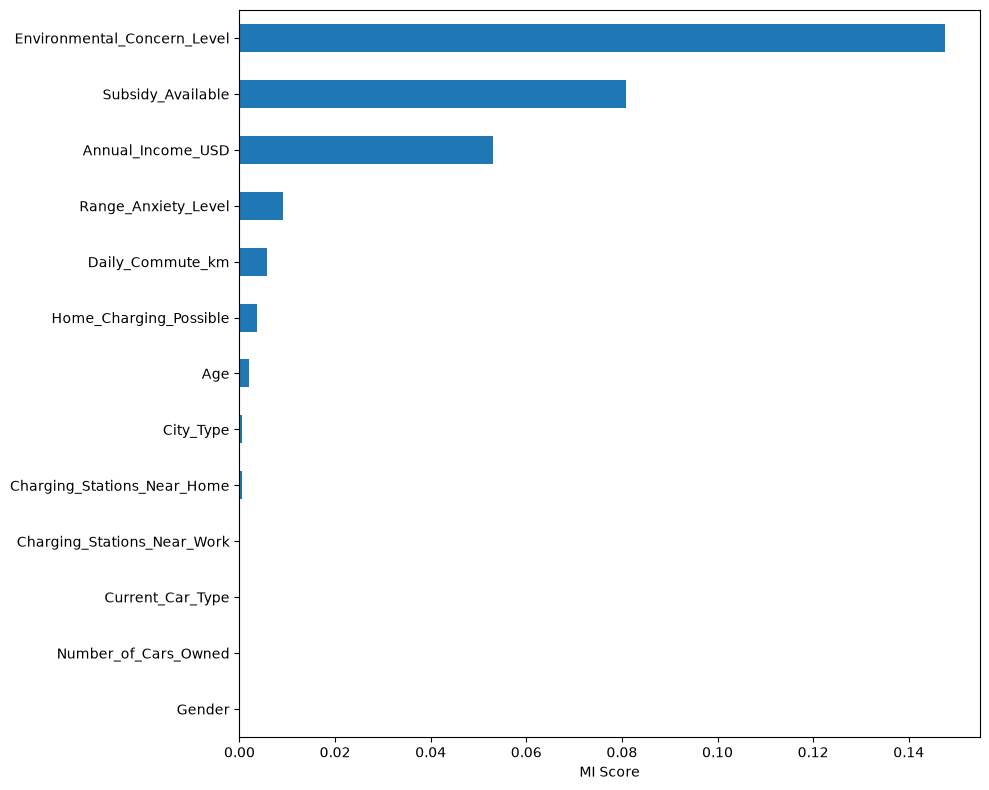

In [11]:
# Calculating MI scores
X_mi = train.drop(columns=['id']).copy()
Y_mi = (X_mi.pop('Will_Buy_EV') == 'Yes').astype(int)

for colname in X_mi.select_dtypes('str'):
    X_mi[colname], _ = X_mi[colname].factorize()

discrete_features = X_mi.dtypes == np.int64

def calc_mi_scores(X, Y, discrete_features):
    mi_scores = mutual_info_classif(X, Y, discrete_features=discrete_features, random_state=42)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    return mi_scores.sort_values(ascending=False)

mi_scores = calc_mi_scores(X_mi, Y_mi, discrete_features)
mi_scores.sort_values().plot.barh(figsize=(10, 8))
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

# **5. Pipeline building**

In [30]:
# Defining a new feature engineering transformer
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, add_cluster=True, add_pca=True, n_clusters=6, n_components=2, random_state=42):
        self.add_cluster = add_cluster
        self.add_pca = add_pca
        self.n_clusters = n_clusters
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X, y=None):
        X = X.copy()
        X['Total_Charging_Stations'] = X['Charging_Stations_Near_Home'] + X['Charging_Stations_Near_Work']

        cluster_features = ['Annual_Income_USD', 'Daily_Commute_km', 'Total_Charging_Stations']
        self.cluster_features_ = cluster_features
        self.scaler_ = StandardScaler().fit(X[cluster_features])
        X_scaled = self.scaler_.transform(X[cluster_features])

        if self.add_cluster:
            self.kmeans_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10).fit(X_scaled)

        if self.add_pca:
            self.pca_ = PCA(n_components=self.n_components, random_state=self.random_state).fit(X_scaled)

        return self

    def transform(self, X):
        X = X.copy()
        X['Total_Charging_Stations'] = X['Charging_Stations_Near_Home'] + X['Charging_Stations_Near_Work']

        X_scaled = self.scaler_.transform(X[self.cluster_features_])

        if self.add_cluster:
            X['Cluster'] = self.kmeans_.predict(X_scaled)
        else:
            X['Cluster'] = 0

        if self.add_pca:
            pcs = self.pca_.transform(X_scaled)
            X['PC1'] = pcs[:, 0]
            X['PC2'] = pcs[:, 1]
        else:
            X['PC1'] = 0.0
            X['PC2'] = 0.0

        return X


In [26]:
# Adding some preprocessing steps to the pipeline
target_encode_cols = ['City_Type', 'Home_Charging_Possible', 'Current_Car_Type', 'Subsidy_Available', 'Range_Anxiety_Level']
target_encode_cols = [c for c in target_encode_cols if c in categorical_cols]


preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols + ['Total_Charging_Stations', 'Cluster', 'PC1', 'PC2']),
    ('target_enc', MEstimateEncoder(m=5.0), target_encode_cols),
    ('onehot', OneHotEncoder(handle_unknown='ignore'), [c for c in categorical_cols if c not in target_encode_cols]),
], remainder='drop')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# **6. Ablation testing**

In [27]:
# Splitting sets
X = train.drop(columns=['id', 'Will_Buy_EV'])
y = (train['Will_Buy_EV'] == 'Yes').astype(int)

X_dev, X_holdout, y_dev, y_holdout = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print('Development set:', X_dev.shape)
print('Holdout set:', X_holdout.shape)
print('Target rate (dev):', round(y_dev.mean(), 4))
print('Target rate (holdout):', round(y_holdout.mean(), 4))

Development set: (534932, 13)
Holdout set: (133733, 13)
Target rate (dev): 0.1746
Target rate (holdout): 0.1746


In [31]:
# Defining feature configurations and base models
feature_configs = {
    'Baseline': {'add_cluster': False, 'add_pca': False},
    '+ Cluster': {'add_cluster': True, 'add_pca': False},
    '+ PCA': {'add_cluster': False, 'add_pca': True},
    '+ All Engineered': {'add_cluster': True, 'add_pca': True},
}

BEST_K = 6

base_models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=15, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=1),
    'LightGBM': LGBMClassifier(n_estimators=200, max_depth=-1, num_leaves=31, learning_rate=0.05, subsample=0.8, subsample_freq=1, verbosity=-1, random_state=RANDOM_STATE, n_jobs=1),
}

In [32]:
# Ablation testing: compare feature sets across models
ablation_results = []

for fs_name, config in feature_configs.items():
    for model_name, model in base_models.items():
        pipe = Pipeline([
            ('features', FeatureEngineer(**config, n_clusters=BEST_K, n_components=2, random_state=RANDOM_STATE)),
            ('preprocess', preprocessor),
            ('model', model),
        ])
        scores = cross_validate(pipe, X_dev, y_dev, cv=cv, scoring={'auc': 'roc_auc', 'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}, n_jobs=-1, return_train_score=False)
        
        ablation_results.append({
            'Model': model_name,
            'Feature Set': fs_name,
            'CV AUC': scores['test_auc'].mean(),
            'AUC Std': scores['test_auc'].std(),
            'Accuracy': scores['test_accuracy'].mean(),
            'Precision': scores['test_precision'].mean(),
            'Recall': scores['test_recall'].mean(),
            'F1': scores['test_f1'].mean(),
        })

ablation_df = pd.DataFrame(ablation_results).sort_values('CV AUC', ascending=False)
display(ablation_df)

,Model,Feature Set,CV AUC,AUC Std,Accuracy,Precision,Recall,F1
7,LightGBM,+ Cluster,0.941303,0.000364,0.898223,0.727150,0.667833,0.696227
3,LightGBM,Baseline,0.941270,0.000323,0.898215,0.727047,0.667973,0.696256
2,XGBoost,Baseline,0.941231,0.000341,0.898015,0.727953,0.664323,0.694678
11,LightGBM,+ PCA,0.941199,0.000361,0.898172,0.727218,0.667234,0.695933
15,LightGBM,+ All Engineered,0.941187,0.000327,0.898161,0.727293,0.666977,0.695828
6,XGBoost,+ Cluster,0.941157,0.000341,0.898069,0.728059,0.664601,0.694879
14,XGBoost,+ All Engineered,0.941098,0.000344,0.897966,0.728178,0.663423,0.694290
10,XGBoost,+ PCA,0.941082,0.000350,0.897899,0.727695,0.663777,0.694262
9,Random Forest,+ PCA,0.938918,0.000311,0.896854,0.732625,0.644681,0.685835
13,Random Forest,+ All Engineered,0.938911,0.000234,0.896849,0.732387,0.645077,0.685961


In [33]:
best_feature_per_model = ablation_df.loc[ablation_df.groupby('Model')['CV AUC'].idxmax()].sort_values('CV AUC', ascending=False)
display(best_feature_per_model[['Model', 'Feature Set', 'CV AUC', 'AUC Std']])

,Model,Feature Set,CV AUC,AUC Std
7,LightGBM,+ Cluster,0.941303,0.000364
2,XGBoost,Baseline,0.941231,0.000341
9,Random Forest,+ PCA,0.938918,0.000311
0,Decision Tree,Baseline,0.937924,0.000212


# **7. Hyperparameter Optimisation**

In [34]:
# Define hyperparameter distributions for RandomizedSearchCV
param_dists = {
    'Decision Tree': {
        'model__max_depth': [5, 10, 15, 20, None],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf': [1, 5, 10],
    },
    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [10, 15, 20, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 5],
        'model__max_features': ['sqrt', 'log2'],
    },
    'XGBoost': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [4, 6, 8, 10],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.7, 0.8, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 1.0],
    },
    'LightGBM': {
        'model__n_estimators': [100, 200, 300, 500],
        'model__max_depth': [5, 10, 15, -1],
        'model__num_leaves': [15, 31, 63, 127],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.7, 0.8, 1.0],
    },
}

In [35]:
# Tune each model using only its best-performing feature set
tuned_searches = {}
tuned_results = []

for _, row in best_feature_per_model.iterrows():
    model_name = row['Model']
    fs_name = row['Feature Set']
    config = feature_configs[fs_name]

    pipe = Pipeline([
        ('features', FeatureEngineer(**config, n_clusters=BEST_K, n_components=2, random_state=RANDOM_STATE)),
        ('preprocess', preprocessor),
        ('model', base_models[model_name]),
    ])

    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_dists[model_name],
        n_iter=12,
        scoring='roc_auc',
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    print(f'Tuning {model_name} using {fs_name}')
    search.fit(X_dev, y_dev)

    tuned_searches[model_name] = search
    tuned_results.append({'Model': model_name, 'Feature Set': fs_name, 'Best CV AUC': search.best_score_})

tuned_results_df = pd.DataFrame(tuned_results).sort_values('Best CV AUC', ascending=False)
display(tuned_results_df)

for name, search in tuned_searches.items():
    print(name, search.best_params_)

Tuning LightGBM using + Cluster
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Tuning XGBoost using Baseline
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Tuning Random Forest using + PCA
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Tuning Decision Tree using Baseline
Fitting 5 folds for each of 12 candidates, totalling 60 fits


,Model,Feature Set,Best CV AUC
0,LightGBM,+ Cluster,0.941693
1,XGBoost,Baseline,0.941382
2,Random Forest,+ PCA,0.939090
3,Decision Tree,Baseline,0.937943


LightGBM {'model__subsample': 0.7, 'model__num_leaves': 63, 'model__n_estimators': 500, 'model__max_depth': 5, 'model__learning_rate': 0.05}
XGBoost {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}
Random Forest {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 15}
Decision Tree {'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 10}


# **8. Model Evaluation**

In [36]:
# Evaluate each tuned model once on the untouched holdout set
evaluation_results = []

for model_name, search in tuned_searches.items():
    pred_prob = search.best_estimator_.predict_proba(X_holdout)[:, 1]
    pred = (pred_prob >= 0.5).astype(int)

    fs_name = best_feature_per_model.loc[best_feature_per_model['Model'] == model_name, 'Feature Set'].iloc[0]

    evaluation_results.append({
        'Model': model_name,
        'Feature Set': fs_name,
        'CV AUC': search.best_score_,
        'Holdout AUC': roc_auc_score(y_holdout, pred_prob),
        'Accuracy': accuracy_score(y_holdout, pred),
        'Precision': precision_score(y_holdout, pred, zero_division=0),
        'Recall': recall_score(y_holdout, pred, zero_division=0),
        'F1': f1_score(y_holdout, pred, zero_division=0),
    })

evaluation_df = pd.DataFrame(evaluation_results).sort_values('Holdout AUC', ascending=False)
display(evaluation_df)

,Model,Feature Set,CV AUC,Holdout AUC,Accuracy,Precision,Recall,F1
0,LightGBM,+ Cluster,0.941693,0.941645,0.898417,0.724900,0.674216,0.698640
1,XGBoost,Baseline,0.941382,0.941423,0.897759,0.722118,0.673917,0.697185
2,Random Forest,+ PCA,0.939090,0.939060,0.896809,0.732416,0.644674,0.685749
3,Decision Tree,Baseline,0.937943,0.938428,0.896062,0.716801,0.669293,0.692233


<Figure size 800x600 with 0 Axes>

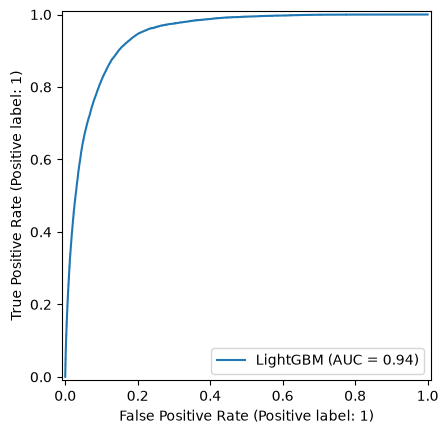

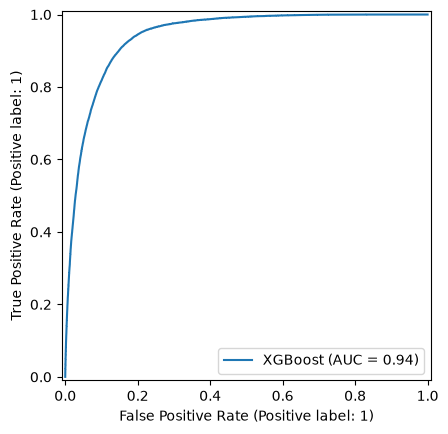

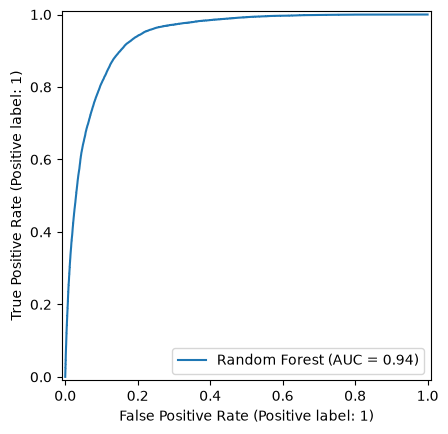

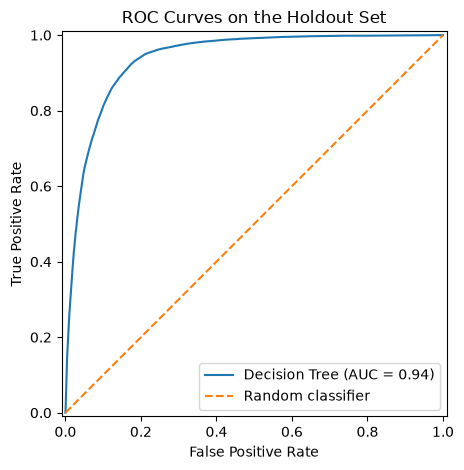

In [37]:
# Plotting ROC curves for every tuned model on the holdout set
plt.figure(figsize=(8, 6))

for model_name, search in tuned_searches.items():
    RocCurveDisplay.from_estimator(search.best_estimator_, X_holdout, y_holdout, name=model_name)

plt.plot([0, 1], [0, 1], linestyle='--', label='Random classifier')
plt.title('ROC Curves on the Holdout Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

Best model: LightGBM
                 precision    recall  f1-score   support

Will not buy EV       0.93      0.95      0.94    110377
    Will buy EV       0.72      0.67      0.70     23356

       accuracy                           0.90    133733
      macro avg       0.83      0.81      0.82    133733
   weighted avg       0.90      0.90      0.90    133733



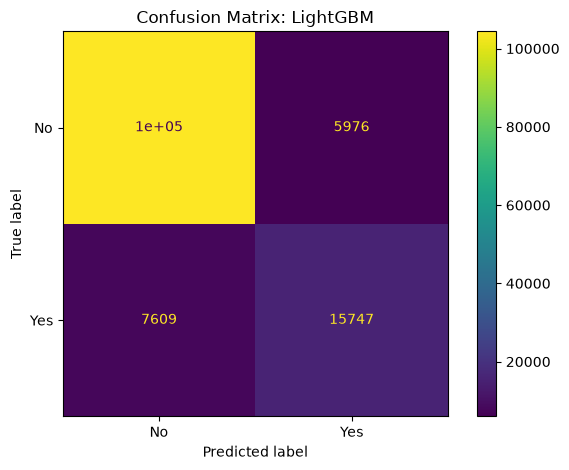

In [38]:
# Selecting the best model and inspecting its holdout performance in detail
best_model_name = evaluation_df.iloc[0]['Model']
best_model = tuned_searches[best_model_name].best_estimator_
holdout_pred = best_model.predict(X_holdout)

print('Best model:', best_model_name)
print(classification_report(y_holdout, holdout_pred, target_names=['Will not buy EV', 'Will buy EV'], zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_holdout, holdout_pred, display_labels=['No', 'Yes'])
plt.title(f'Confusion Matrix: {best_model_name}')
plt.tight_layout()
plt.show()

# **9. Feature importance**

In [40]:
# Extracting feature importance from the winning model
fitted_preprocessor = best_model.named_steps['preprocess']
fitted_model = best_model.named_steps['model']

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_model.feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)

display(importance_df.head(20))

,Feature,Importance
1,num__Annual_Income_USD,4255
2,num__Daily_Commute_km,2311
0,num__Age,1885
6,num__Environmental_Concern_Level,1234
7,num__Total_Charging_Stations,1108
4,num__Charging_Stations_Near_Home,868
5,num__Charging_Stations_Near_Work,835
15,target_enc__Range_Anxiety_Level,543
13,target_enc__Current_Car_Type,392
3,num__Number_of_Cars_Owned,382


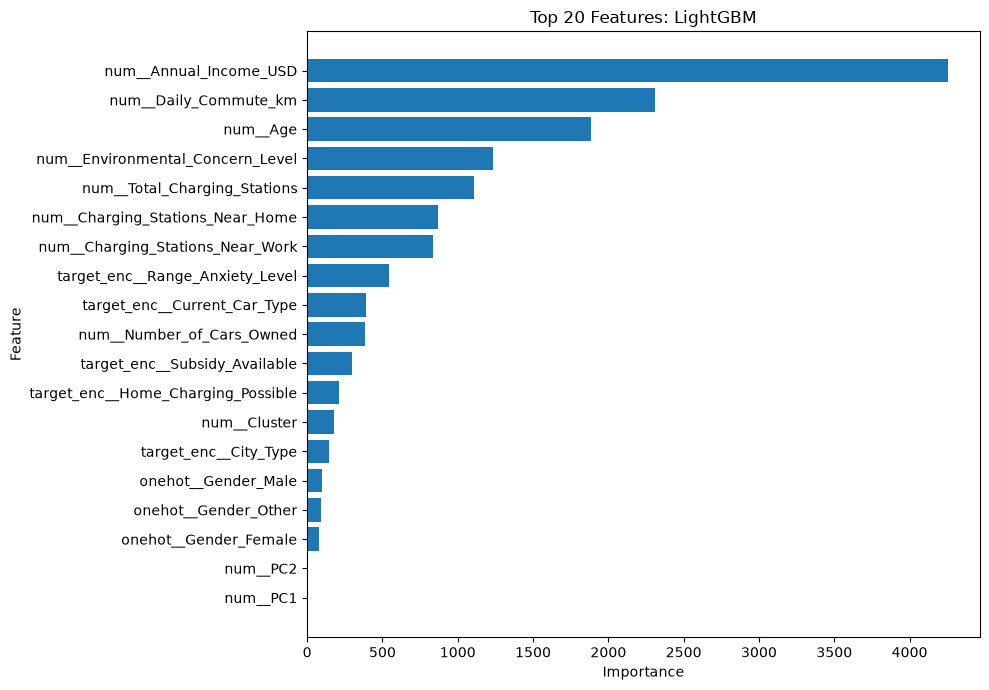

In [41]:
# Plotting the top 20 most important features
top20 = importance_df.head(20).sort_values('Importance')

plt.figure(figsize=(10, 7))
plt.barh(top20['Feature'], top20['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Top 20 Features: {best_model_name}')
plt.tight_layout()
plt.show()

# **10. Final model modification**

In [42]:
# Refit the winning pipeline on the full training set before final prediction
best_params = tuned_searches[best_model_name].best_params_

final_pipeline = Pipeline([
    ('features', FeatureEngineer(add_cluster=True, add_pca=False, n_clusters=BEST_K, n_components=2, random_state=RANDOM_STATE)),
    ('preprocess', preprocessor),
    ('model', base_models[best_model_name]),
])

final_pipeline.set_params(**best_params)
final_pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,add_pca,False
,add_cluster,True
,n_clusters,6
,n_components,2
,random_state,42


# **11. Model prediction**

In [43]:
# Generating predictions on the competition test set
X_test = test.drop(columns=['id'])

test_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]

print(test_pred_proba[:10])

[9.84644863e-03 1.61993350e-02 4.89365023e-03 2.97884989e-03
 1.91156361e-02 4.47019769e-03 3.67532505e-01 2.90932895e-04
 6.62921045e-01 4.55402924e-03]


In [44]:
# Building the final submission file
submission = pd.DataFrame({
    'id': test['id'],
    'Will_Buy_EV': test_pred_proba
})

submission.to_csv('submission.csv', index=False)
print(submission.head())

       id  Will_Buy_EV
0  668665     0.009846
1  668666     0.016199
2  668667     0.004894
3  668668     0.002979
4  668669     0.019116
